# Experiments vs simulations: Quads design (3dp pla + blue shims) for static cloaking of a circular stress-free region


## Imports

In [1]:
import jax
import matplotlib.pyplot as plt
from typing import Union
from mechanicalmetamaterialcloaks.plotting import generate_animation
from mechanicalmetamaterialcloaks.utils import save_data, load_data, SolutionData
from problems.quads_static_cloaking_stress_free import OptimizationProblem
from mechanicalmetamaterialcloaks.plotting import plot_video_frame_field_overlaid, plot_geometry_field_overlaid
from scipy import interpolate

from pathlib import Path
import pandas as pd
from scripts.tracking.utils import smooth_fields_SG
import jax.numpy as jnp
from jax import random
jax.config.update("jax_enable_x64", True)  # enable float64 type

plt.style.use(["science", "grid"])
%matplotlib widget

## Paths

In [2]:
# Where to load/save data
data_folder = Path("../../../data/quads_static_cloaking_3dp_pla_shims_stress_free")
data_folder_reference_compressed = Path("../../../data/quads_static_cloaking_3dp_pla_shims_reference_compressed")
# Where to save plots and animations
out_folder = Path("../../../out/quads_static_cloaking_3dp_pla_shims_stress_free")

## Problem info

NOTE: Either define the problem info here or load it from an optimization file.

In [3]:
# NOTE: Units are mm, N, s

# Retrieve design info from optimization data
optimization_filename = f"opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_circle_stress_free"
optimization = OptimizationProblem.from_dict(
    load_data(
        f"{data_folder}/{optimization_filename}.pkl",
    )
)
problem = optimization.forward_problem
# Set up the forward problem to get the geometry
problem.setup()
geometry = problem.geometry

# Select the best design
design_values = optimization.design_values[-1]

compute solution MG done
setup forward done


## Experimental video paths


In [4]:
# Subfolder for videos and tracking data
design_name = optimization_filename

# Experimental videos to be processed - Reference design
video_paths_reference = sorted(
    list(Path(f"{data_folder_reference_compressed}/videos").glob("*.mp4"))
)
# Experimental videos to be processed - Cloaked design
video_paths_cloaked = sorted(
    list(Path(f"{data_folder}/{design_name}/videos").glob("cloaked_*.mp4"))
)
video_paths = video_paths_reference + video_paths_cloaked

## Load tracking data


### Reference compressed design

In [5]:
# Find all data files in the dynamic-data folder
tracked_data_paths_reference = sorted(list(Path(
    f"{data_folder_reference_compressed}/dynamic-data/tracking_exp/").glob("*.pkl")))

# Load the tracked data as a dataframe
tracked_data_reference = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths_reference],
    "video_path": video_paths_reference,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths_reference],
})

# Smooth tracking data
tracked_data_reference.data = tracked_data_reference.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[7, 7, 20], [7, 7, 20]], polyorder=2)),
    axis=1,
)

### Cloaked design

In [6]:
# Find all data files in the dynamic-data folder
tracked_data_paths = sorted(list(Path(f"{data_folder}/{design_name}/dynamic-data/tracking_exp/").glob("*.pkl")))

# Load the tracked data as a dataframe
tracked_data_cloaked = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths],
    "video_path": video_paths_cloaked,
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths],
})

# Smooth tracking data
tracked_data_cloaked.data = tracked_data_cloaked.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[10, 10, 25], [10, 10, 25]], polyorder=2)),
    axis=1,
)

### Concatenate dataframes

In [7]:
tracked_data = pd.concat([tracked_data_reference, tracked_data_cloaked], ignore_index=True)
tracked_data

,label,video_path,data
0,reference_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [30.086111807800044, 0.41766143..."
1,cloaked_stress_free,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [29.867175334342164, 0.00991152..."


## Plot deformation fields

### Helper functions

In [8]:
def scaled_to_unscaled_idx(x, array):
    """Return the index in the unscaled array corresponding to the scaled index x."""
    return int(x * (len(array) - 1))

In [9]:
def plot_snapshot_experiment(
        df_row: pd.Series,
        field: str,
        time: float,
        cmap="inferno",
        alpha_overlay=0.8,
        vlim=None,
        figsize=(4, 4),
        ax=None,):
    """Plot a snapshot of the experiment."""

    vmin, vmax = vlim if vlim is not None else (None, None)
    timepoint = scaled_to_unscaled_idx(time, df_row.data.timepoints)
    fig, axes = plot_video_frame_field_overlaid(
        video_filename=df_row.video_path,
        solution_data=df_row.data,
        field=field,
        frame_number=df_row.frame_start+timepoint*df_row.step_size,
        timepoint=timepoint,
        calib_xy=df_row.calib_xy,
        ROI_X=df_row.ROI_X,
        ROI_Y=df_row.ROI_Y,
        shift_px=df_row.shift_px,
        alpha_overlay=alpha_overlay,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        figsize=figsize,
        ax=ax,
    )
    return fig, axes


def plot_snapshot_simulation(
        solution_data: SolutionData,
        field: str,
        time: float,
        cmap="inferno",
        figsize=(4, 4),
        xlim=None,
        ylim=None,
        vlim=None,
        ax=None,):
    """Plot a snapshot of the simulation."""

    timepoint = scaled_to_unscaled_idx(time, solution_data.timepoints)
    fig, axes = plot_geometry_field_overlaid(
        data=solution_data,
        field=field,
        timepoint=timepoint,
        deformed=True,
        cmap=cmap,
        xlim=xlim,
        ylim=ylim,
        vlim=vlim,
        colorbar=False,
        figsize=figsize,
        axis=False,
        ax=ax,
    )
    return fig, axes


def resample_simulation_data(data: SolutionData, n_samples: int = 400):
    """Resample simulation data to match the experimental data (i.e. linear loading/unloading ramp)."""
    normalized_applied_displacement = problem.applied_displacement(
        data.timepoints/data.timepoints[-1], 1., 1.)
    interpolated_fields_loading = interpolate.make_interp_spline(
        x=0.5*normalized_applied_displacement,
        y=data.fields,
        k=3,
        axis=0,
    )

    def interpolated_fields_loading_unloading(t):
        return interpolated_fields_loading(-jnp.abs(t-0.5)+0.5)

    normalized_timepoints = jnp.linspace(0, 1, n_samples)
    return data._replace(
        fields=interpolated_fields_loading_unloading(
            normalized_timepoints
        ),
        timepoints=normalized_timepoints,
    )

### Experiments

In [10]:
# Plotting parameters for each experiment i.e. each row of the tracked_data dataframe
plot_params = dict(
    calib_xy=[(0.268, 0.268), (0.34, 0.34)],
    ROI_X=[(50, 1050), (215, 1003)],
    ROI_Y=[(440, 1370), (532, 1265)],
    shift_px=[(105, 70), (85, 57)],
    frame_start=[400, 90],
    step_size=[35, 9],
)
# Add plot params to the tracked_data dataframe
for key, value in plot_params.items():
    tracked_data[key] = value
tracked_data

,label,video_path,data,calib_xy,ROI_X,ROI_Y,shift_px,frame_start,step_size
0,reference_compressed,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [30.086111807800044, 0.41766143...","(0.268, 0.268)","(50, 1050)","(440, 1370)","(105, 70)",400,35
1,cloaked_stress_free,../../../data/quads_static_cloaking_3dp_pla_sh...,"([[15.0, 0.0], [29.867175334342164, 0.00991152...","(0.34, 0.34)","(215, 1003)","(532, 1265)","(85, 57)",90,9


In [11]:
normalized_timepoints = [0., 0.2, 0.4, 0.5]

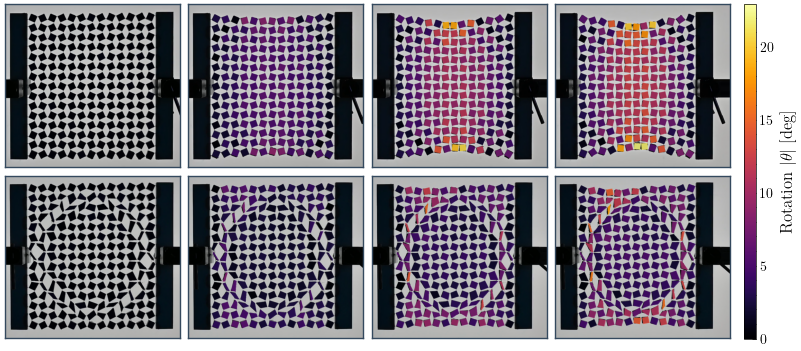

In [45]:
vlim = (
    0,
    0.4,  # tracked_data.data.apply(lambda x: jnp.abs(x.fields[:,0,:,2]).max()).max()
)
plt.close("all")
fig, axes = plt.subplots(ncols=len(normalized_timepoints),
                         nrows=tracked_data.shape[0], figsize=(2*4, 3.5), constrained_layout=True)
for i, row in tracked_data.iterrows():
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_experiment(df_row=row, field="theta_abs", time=time, ax=axes[i, j], vlim=vlim, alpha_overlay=0.9)
# Make all spines 1pt thick and color #34495e
for ax in axes.flatten():
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_color("#34495e")
# Add colorbar
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1]*180/jnp.pi)
sm = plt.cm.ScalarMappable(cmap="inferno", norm=norm)
cbar = fig.colorbar(sm, ax=axes, location="right", aspect=30, pad=0.02)
cbar.ax.set_yticks([0, 5, 10, 15, 20])
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_ylabel(r"Rotation $\lvert\theta\rvert$ [deg]", fontsize=12)
# Save figure
out_path = out_folder / optimization_filename / "reference_vs_cloaked_exp.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

### Simulations: Nominal geometry

In [13]:
# Nominal geometry
simulation_datas = problem.solution_data[1:]
simulation_data_resampled = [
    resample_simulation_data(data)
    for data in simulation_datas
]

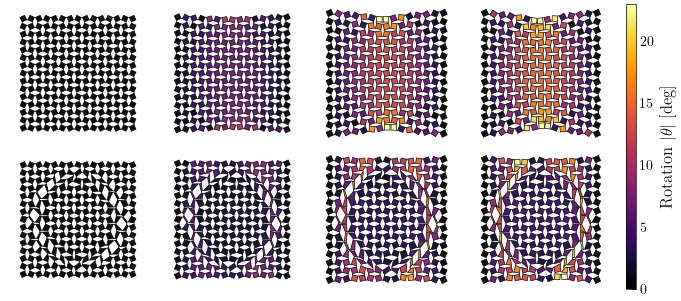

In [14]:
vlim = (
    0,
    0.4, #max([jnp.abs(sim_data.fields[:,0,:,2]).max() for sim_data in simulation_data_resampled])
)

xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + 2*jnp.array([[-0.5, 0.5],[-0.5, 0.5]])*problem.spacing
plt.close("all")
fig, axes = plt.subplots(ncols=len(normalized_timepoints), nrows=len(simulation_data_resampled), figsize=(1.7*4, 3.), constrained_layout=True)
for i, simulation_data in enumerate(simulation_data_resampled):
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_simulation(
            solution_data=simulation_data,
            field="theta_abs",
            time=time,
            xlim=xlim,
            ylim=ylim,
            ax=axes[i, j],
            vlim=vlim,
        )
        axes[i, j].axis("equal")
# Add colorbar
norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1]*180/jnp.pi)
sm = plt.cm.ScalarMappable(cmap="inferno", norm=norm)
cbar = fig.colorbar(sm, ax=axes, location="right", aspect=30, pad=0.02)
cbar.ax.set_yticks([0, 5, 10, 15, 20])
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_ylabel(r"Rotation $\lvert\theta\rvert$ [deg]", fontsize=12)
# Save figure
out_path = out_folder / optimization_filename / "reference_vs_cloaked_sim_nominal.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

### Simulations: Perturbed geometry

In [15]:
# Nominal geometry
simulation_datas = problem.solution_data[1:]
simulation_data_resampled = [
    resample_simulation_data(data)
    for data in simulation_datas
]

In [16]:
# Perturbed geometry
def perturb_array(array, key, noise_amplitude=0.1):
    return array + random.uniform(random.PRNGKey(key), array.shape, minval=-1, maxval=1)*noise_amplitude


def perturb_design_value(design_value, key, noise_amplitude=0.1):
    return (perturb_array(design_value[0], key, noise_amplitude),
            perturb_array(design_value[1], key+1, noise_amplitude))

key = 2
noise_amplitude = 0.03

solution_data_perturbed = optimization.forward_problem.solve_all_shifts(
    perturb_design_value(
        optimization.forward_problem.cloak_to_all_shifts(
            design_values
        ),
        key,
        noise_amplitude*optimization.forward_problem.spacing,
    )
)

In [ ]:
simulation_datas = [problem.solution_data[1], solution_data_perturbed]
simulation_data_resampled = [
    resample_simulation_data(data)
    for data in simulation_datas
]

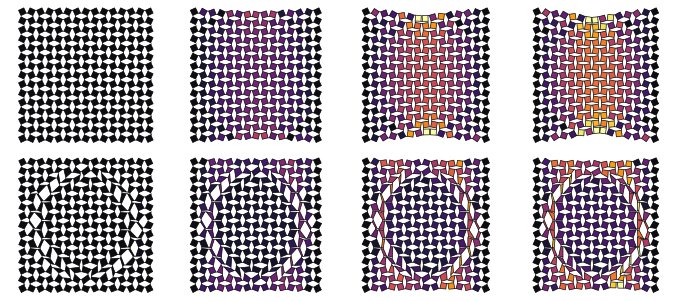

In [58]:
vlim = (
    0,
    0.4, #max([jnp.abs(sim_data.fields[:,0,:,2]).max() for sim_data in simulation_data_resampled])
)

xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + 2*jnp.array([[-0.5, 0.5],[-0.5, 0.5]])*problem.spacing
plt.close("all")
fig, axes = plt.subplots(ncols=len(normalized_timepoints), nrows=len(simulation_data_resampled), figsize=(1.7*4, 3.), constrained_layout=True)
for i, simulation_data in enumerate(simulation_data_resampled):
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_simulation(
            solution_data=simulation_data,
            field="theta_abs",
            time=time,
            xlim=xlim,
            ylim=ylim,
            ax=axes[i, j],
            vlim=vlim,
        )
        axes[i, j].axis("equal")
# Add colorbar
# norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1]*180/jnp.pi)
# sm = plt.cm.ScalarMappable(cmap="inferno", norm=norm)
# cbar = fig.colorbar(sm, ax=axes, location="right", aspect=30, pad=0.02)
# cbar.ax.set_yticks([0, 5, 10, 15, 20])
# cbar.ax.tick_params(labelsize=10)
# cbar.ax.set_ylabel(r"Rotation $\lvert\theta\rvert$ [deg]", fontsize=12)
# Save figure
out_path = out_folder / optimization_filename / "reference_vs_cloaked_sim.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

#### Sweep over random geometric imperfections

In [ ]:
# noise_amplitude = 0.05  # 0.01, 0.02, 0.03, 0.05
# keys = jnp.arange(10)

# solution_data_perturbed_sweep = [
#     optimization.forward_problem.solve_all_shifts(
#         perturb_design_value(
#             optimization.forward_problem.cloak_to_all_shifts(
#                 design_values
#             ),
#             key,
#             noise_amplitude*optimization.forward_problem.spacing,
#         )
#     )
#     for key in keys
# ]

# # Save perturbed solution data
# save_data(
#     f"{data_folder}/{optimization_filename}/solution_data_perturbed_noise_{noise_amplitude:.2f}.pkl",
#     [sd._asdict() for sd in solution_data_perturbed_sweep],
# )

Data saved at ../../../data/quads_static_cloaking_3dp_pla_shims_stress_free/opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_circle_stress_free/solution_data_perturbed_noise_0.05.pkl


### Experiments vs simulations

#### Average rotation vs compression (proxy for stress)

In [32]:
def tracked_to_all_blocks_fields(tracked_fields):
    all_blocks_fields = jnp.zeros((tracked_fields.shape[0], tracked_fields.shape[1], geometry.n_blocks, 3))
    all_blocks_fields = all_blocks_fields.at[:, :, problem.moving_blocks_ids].set(tracked_fields)
    return all_blocks_fields

In [ ]:
noise_amplitude = 0.03
key = 2
solution_data_perturbed = SolutionData(
    **load_data(
        f"{data_folder}/{optimization_filename}/solution_data_perturbed_noise_{noise_amplitude:.2f}.pkl"
    )[key]
)
simulation_datas = [problem.solution_data[1], solution_data_perturbed]
simulation_data_resampled = [
    resample_simulation_data(data)
    for data in simulation_datas
]

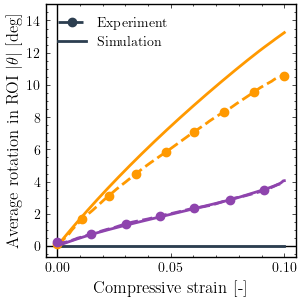

In [35]:
exp_average_rotation = tracked_data.data.apply(
    lambda data: jnp.abs(tracked_to_all_blocks_fields(data.fields)[:, 0, problem.inclusion_IDs, 2]).mean(axis=-1)
)
sim_average_rotation = jnp.array([
    jnp.abs(simulation_data.fields[:, 0, problem.inclusion_IDs, 2]).mean(axis=-1)
    for simulation_data in simulation_data_resampled
])
# Resample the experimental data with timepoints between 0 and 1
exp_average_rotation = jnp.array([
    jnp.interp(
        jnp.linspace(0, tracked_data.data[i].timepoints[-1], sim_average_rotation[0].shape[0]),
        tracked_data.data[i].timepoints,
        data
    )
    for i, data in enumerate(exp_average_rotation)
])
compressions = jnp.concatenate([
    jnp.linspace(0, 0.1, sim_average_rotation[0].shape[0]//2),
    jnp.linspace(0.1, 0, sim_average_rotation[0].shape[0]//2)
])
# Plot the average rotation
cloaked_color = "#8e44ad"
altered_color = "#ff9900"
colors = [altered_color, cloaked_color]
plt.close("all")
fig, ax = plt.subplots(figsize=(3, 3), constrained_layout=True)
for (i, row), color in zip(tracked_data.iterrows(), colors):
    # Exp
    ax.plot(compressions[:200], exp_average_rotation[i][:200]*180/jnp.pi,
            label=row.label, lw=2, ls="--", marker="o", markevery=0.1, markersize=6, color=color)
    # Sim
    ax.plot(compressions[:200], sim_average_rotation[i][:200]*180/jnp.pi,
            label=f"Sim {i}", linestyle="-", lw=2, color=color)

# Add reference that has zero rotation
ax.plot(compressions[:200], jnp.zeros_like(compressions[:200]), linestyle="-", lw=2, color="#2c3e50", label="Reference", zorder=1)
ax.set_xlabel("Compressive strain [-]", fontsize=12)
ax.set_ylabel(r"Average rotation in ROI $\lvert\theta\rvert$ [deg]", fontsize=12)
ax.tick_params(labelsize=10)
ax.set_xticks([0, 0.05, 0.1])
ax.axhline(0, color="k", lw=1, zorder=0)
ax.axvline(0, color="k", lw=1, zorder=0)
ax.set_ylim(None, 15)
# Spines 1pt thick
for spine in ax.spines.values():
    spine.set_linewidth(1)
ax.grid(False)
# Add custom legend
handles = [
    plt.Line2D([0], [0], color="#2c3e50", lw=2, ls="--", marker="o", markersize=6, label="Experiment"),
    plt.Line2D([0], [0], color="#2c3e50", lw=2, label="Simulation")
]
legend = ax.legend(
    handles=handles,
    loc="upper left",
    fontsize=10,
    frameon=False,
)
# Save figure
# out_path = out_folder / optimization_filename / "average_rotation_in_ROI_cloaked_vs_reference.png"
# out_path.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

#### Average rotation vs compression (proxy for stress): Sensitivity to geometric imperfections

In [73]:
noise_amplitudes = [0.01, 0.03, 0.05]
simulation_data_perturbed_sweep = [
    [
        resample_simulation_data(SolutionData(**data_dict)) for data_dict in load_data(
            f"{data_folder}/{optimization_filename}/solution_data_perturbed_noise_{noise_amplitude:.2f}.pkl"
        )
    ]
    for noise_amplitude in noise_amplitudes
]
simulation_data_nominal = [resample_simulation_data(data) for data in problem.solution_data[1:]]

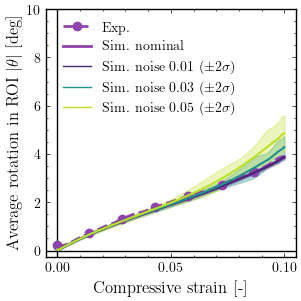

In [77]:
exp_average_rotation = tracked_data.data.apply(
    lambda data: jnp.abs(tracked_to_all_blocks_fields(data.fields)[:, 0, problem.inclusion_IDs, 2]).mean(axis=-1)
)
# Resample the experimental data with timepoints between 0 and 1
exp_average_rotation = jnp.array([
    jnp.interp(
        jnp.linspace(0, tracked_data.data[i].timepoints[-1], simulation_data_nominal[0].timepoints.shape[0]),
        tracked_data.data[i].timepoints,
        data
    )
    for i, data in enumerate(exp_average_rotation)
])
# Compute the average rotation for the nominal simulation
sim_average_rotation_nominal = jnp.array([
    jnp.abs(simulation_data.fields[:, 0, problem.inclusion_IDs, 2]).mean(axis=-1)
    for simulation_data in simulation_data_nominal
])
# Compute the average rotation for each noise amplitude
sim_average_rotation_sweep = jnp.array([
    jnp.array([
        jnp.abs(simulation_data.fields[:, 0, problem.inclusion_IDs, 2]).mean(axis=-1)
        for simulation_data in simulation_data_perturbed_noise
    ]).mean(axis=0) for simulation_data_perturbed_noise in simulation_data_perturbed_sweep
])
# Compute the std deviation of the average rotation for each noise amplitude
sim_average_rotation_sweep_std = jnp.array([
    jnp.array([
        jnp.abs(simulation_data.fields[:, 0, problem.inclusion_IDs, 2]).mean(axis=-1)
        for simulation_data in simulation_data_perturbed_noise
    ]).std(axis=0) for simulation_data_perturbed_noise in simulation_data_perturbed_sweep
])

compressions = jnp.concatenate([
    jnp.linspace(0, 0.1, simulation_data_nominal[0].timepoints.shape[0]//2),
    jnp.linspace(0.1, 0, simulation_data_nominal[0].timepoints.shape[0]//2)
])

# Plot the average rotation
cloaked_color = "#8e44ad"
altered_color = "#ff9900"
colors = [altered_color, cloaked_color]
noise_colors = plt.cm.viridis(jnp.linspace(0.1, 0.9, len(noise_amplitudes)))

plt.close("all")
fig, ax = plt.subplots(figsize=(3., 3.), constrained_layout=True)
for (i, row), color in zip(tracked_data[1:].iterrows(), colors[1:]):
    # Exp
    ax.plot(compressions[:200], exp_average_rotation[i][:200]*180/jnp.pi,
            label=row.label, lw=2, ls="--", marker="o", markevery=0.1, markersize=6, color=color)
    # Sim nominal
    ax.plot(compressions[:200], sim_average_rotation_nominal[i][:200]*180/jnp.pi,
            label=f"Sim nominal {i}", linestyle="-", lw=2, color=color)

for noise, color, sim_average_rotation, sim_average_rotation_std in zip(noise_amplitudes, noise_colors, sim_average_rotation_sweep, sim_average_rotation_sweep_std):
    # Sim average rotation with std shading
    ax.plot(compressions[:200], sim_average_rotation[:200]*180/jnp.pi,
            label=f"Sim noise {noise:.2f}", linestyle="-", lw=1.5, color=color)
    ax.fill_between(
        compressions[:200],
        (sim_average_rotation[:200] - 2*sim_average_rotation_std[:200])*180/jnp.pi,
        (sim_average_rotation[:200] + 2*sim_average_rotation_std[:200])*180/jnp.pi,
        color=color,
        alpha=0.3,
        # zorder=0,
    )

# Add reference that has zero rotation
# ax.plot(compressions[:200], jnp.zeros_like(compressions[:200]),
#         linestyle="-", lw=2, color="#2c3e50", label="Reference", zorder=1)
ax.set_xlabel("Compressive strain [-]", fontsize=12)
ax.set_ylabel(r"Average rotation in ROI $\lvert\theta\rvert$ [deg]", fontsize=12)
ax.tick_params(labelsize=10)
ax.set_xticks([0, 0.05, 0.1])
ax.axhline(0, color="k", lw=1, zorder=0)
ax.axvline(0, color="k", lw=1, zorder=0)
ax.set_ylim(None, 10)
# Spines 1pt thick
for spine in ax.spines.values():
    spine.set_linewidth(1)
ax.grid(False)
# Add custom legend
handles = [
    plt.Line2D([0], [0], color=cloaked_color, lw=2, ls="--", marker="o", markersize=6, label="Exp."),
    plt.Line2D([0], [0], color=cloaked_color, lw=2, label="Sim. nominal"),
] + [
    plt.Line2D([0], [0], color=color, lw=1, label=f"Sim. noise {noise:.2f} ($\pm2\sigma$)")
    for noise, color in zip(noise_amplitudes, noise_colors)
]
legend = ax.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.02, 1),
    fontsize=10,
    frameon=False,
)
# Save figure
out_path = out_folder / optimization_filename / "average_rotation_in_ROI_cloaked_vs_reference_sensitivity.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

#### Snapshots

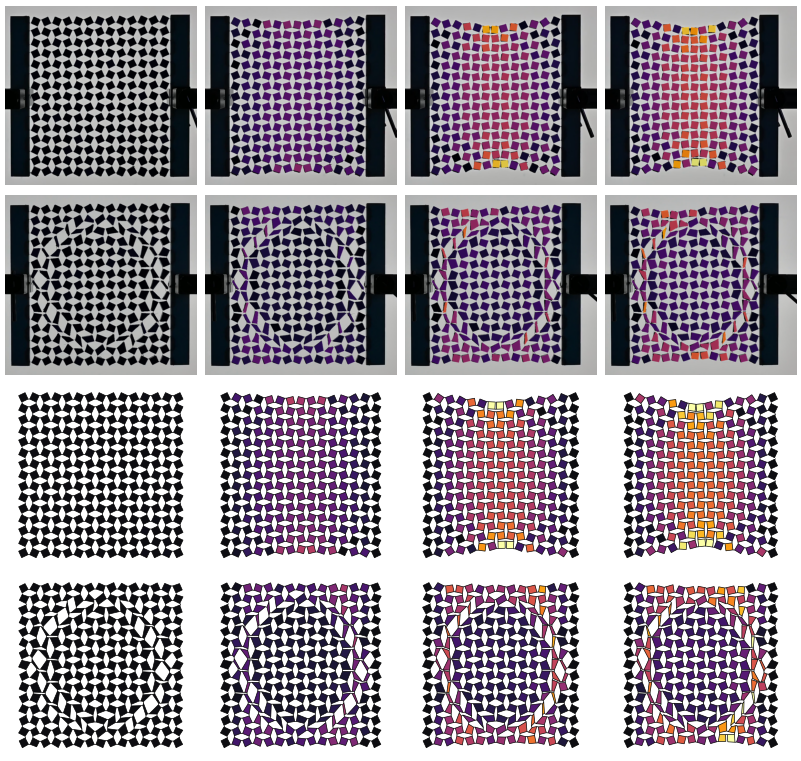

In [ ]:
normalized_timepoints = [0., 0.2, 0.4, 0.5]
vlim = (0, 0.4)
field = "theta_abs"
cmap = "inferno"

plt.close("all")
xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + jnp.array([[-3.5, 3.5],[-3.5, 3.5]])*problem.spacing
fig, axes = plt.subplots(ncols=len(normalized_timepoints), nrows=tracked_data.shape[0]*2, figsize=(2*4, 1.9*4), constrained_layout=True)
for i, row in tracked_data.iterrows():
    for j, time in enumerate(normalized_timepoints):
        plot_snapshot_experiment(
            df_row=row,
            field=field,
            cmap=cmap,
            time=time,
            vlim=vlim,
            alpha_overlay=0.9,
            ax=axes[i, j],
        )
        plot_snapshot_simulation(
            solution_data=simulation_data_resampled[i],
            field=field,
            cmap=cmap,
            time=time,
            xlim=xlim,
            ylim=ylim,
            vlim=vlim,
            ax=axes[2+i, j],
        )
        axes[i, j].axis("equal")
        axes[2+i, j].axis("equal")

# Save figure
out_path = out_folder / optimization_filename / "reference_vs_cloaked_perturbed_exp_vs_sim.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300, bbox_inches="tight")

#### Export all frames: Experiments vs simulations

In [ ]:
import tqdm


plt.ioff()
plt.close("all")
xlim, ylim = geometry.get_xy_limits(*problem.cloak_to_all_shifts(design_values)) + \
    jnp.array([[-3.5, 3.5], [-3.5, 3.5]])*problem.spacing
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(2*4, 1.9*4), constrained_layout=True)

normalized_timepoints = jnp.linspace(0, 1., 200)
field = "theta_abs"
cmap = "inferno"
vlim = (0., 0.36)

for t, time in enumerate(tqdm.tqdm(normalized_timepoints, desc="Exporting frames")):
    for i, row in tracked_data.iterrows():
        plot_snapshot_experiment(
            df_row=row,
            field=field,
            cmap=cmap,
            time=time,
            vlim=vlim,
            ax=axes[i, 0],
        )
        plot_snapshot_simulation(
            solution_data=simulation_data_resampled[i],
            field=field,
            cmap=cmap,
            time=time,
            xlim=xlim,
            ylim=ylim,
            vlim=vlim,
            ax=axes[i, 1],
        )
    # Set all axis to be equal
    for ax in axes.flatten():
        ax.axis("equal")
    # Save figure
    out_path = out_folder / optimization_filename / "exp_vs_sim_frames" / f"frame_{t:03d}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=300)
    for ax in axes.flatten():
        ax.clear()
plt.ion()

# # Export colorbar
# fig, ax = plt.subplots(figsize=(0.2, 5))
# cmap = plt.cm.inferno
# norm = plt.Normalize(vmin=jnp.rad2deg(vlim[0]), vmax=jnp.rad2deg(vlim[1]))
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# cbar = fig.colorbar(sm, cax=ax, orientation='vertical', label=r'$|\theta|$ -- Rotation (deg)')
# cbar.ax.yaxis.label.set_size(18)
# cbar.ax.tick_params(labelsize=16)
# fig.savefig(out_folder / optimization_filename / "colorbar.png", dpi=300, bbox_inches='tight')
# plt.close(fig)
